# Canine Wellness Project - CSCA5622 Final Project

## Project Overview
This project is based on the Kaggle dataset [Canine Wellness Dataset (Synthetic 10K Samples)](https://www.kaggle.com/datasets/aaronisomaisom3/canine-wellness-dataset-synthetic-10k-samples), which contains 10,000 synthetic samples of canine health and lifestyle data. The dataset includes features such as age, weight, diet, activity level, and medical history.

## Github link for this project:
https://github.com/CanoANO/Canine_Wellness_Research

## Research Objective
The project aims to answer the following question:

- **Main Question**: Across different age groups of dogs, which features are most important in predicting whether a dog has a disease?  
- **Learning Task**: This is a supervised binary classification problem, with `Healthy` as the target variable (True = healthy, False = unhealthy).  
- **Approach**:  
  1. Conduct exploratory data analysis (EDA) to understand feature distributions and their relationships with disease status.  
  2. Build classification models (Gradient Boosting, SVM).  
  3. Train models separately for different age groups (Puppy, Young, Adult, Senior, Geriatric) to compare feature importance.  
  4. Summarize findings and discuss implications of the results.  

Through this study, we aim to provide insights into canine health monitoring and disease prediction, offering useful perspectives for pet owners and veterinarians.

Import dependencies:

In [1]:
import warnings
warnings.simplefilter('ignore')
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set color map to have light blue background
sns.set()
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

sys.path.append(os.path.abspath('.'))
from utils import Utils

%matplotlib inline

## Data Loading and Exploration

In [2]:
utils = Utils()
# Load the dataset
data_path = utils.download_csv()
df = pd.read_csv(data_path, encoding='ascii', delimiter=',')

# Display the top rows of the dataset
print('First few rows of the dataset:')
display(df.head())

# Display basic info about the dataset
print('\nDataset Information:')
display(df.info())

# Summary statistics for numeric columns
print('\nSummary Statistics:')
display(df.describe())

File already exists in ./data/canine-wellness-dataset-synthetic-10k-samples
First few rows of the dataset:


,ID,Breed,Breed Size,Sex,Age,Weight (lbs),Spay/Neuter Status,Daily Activity Level,Diet,Food Brand,...,Other Pets in Household,Medications,Seizures,Hours of Sleep,Play Time (hrs),Owner Activity Level,Annual Vet Visits,Average Temperature (F),Synthetic,Healthy
0,1,Australian Shepherd,Medium,Male,3.0,60.0,Neutered,NaN,NaN,Wellness,...,No,Yes,No,12.0,1.0,Active,1.0,30.0,Yes,Yes
1,2,Dachshund,NaN,Female,4.0,57.0,Neutered,Very Active,Home cooked,Special,...,Yes,No,No,11.0,3.0,NaN,0.0,47.0,Yes,NaN
2,3,Chihuahua,Small,Female,12.0,67.0,Neutered,Active,Home cooked,Special,...,Yes,No,No,10.0,1.0,Low,0.0,92.0,Yes,Yes
3,4,Siberian Husky,Medium,Male,13.0,35.0,NaN,Very Active,NaN,Special,...,No,No,No,12.0,NaN,NaN,1.0,75.0,Yes,Yes
4,5,Boxer,Medium,Male,13.0,35.0,NaN,Very Active,Wet food,Purina,...,Yes,Yes,No,9.0,1.0,NaN,0.0,64.0,Yes,No



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           10000 non-null  int64  
 1   Breed                        9710 non-null   object 
 2   Breed Size                   9712 non-null   object 
 3   Sex                          9675 non-null   object 
 4   Age                          9709 non-null   float64
 5   Weight (lbs)                 9709 non-null   float64
 6   Spay/Neuter Status           6433 non-null   object 
 7   Daily Activity Level         7770 non-null   object 
 8   Diet                         9698 non-null   object 
 9   Food Brand                   9700 non-null   object 
 10  Daily Walk Distance (miles)  9706 non-null   float64
 11  Other Pets in Household      9702 non-null   object 
 12  Medications                  9751 non-null   object 


None


Summary Statistics:


,ID,Age,Weight (lbs),Daily Walk Distance (miles),Hours of Sleep,Play Time (hrs),Annual Vet Visits,Average Temperature (F)
count,10000.00000,9709.000000,9709.000000,9706.000000,9721.000000,9691.000000,9694.000000,9655.000000
mean,5000.50000,7.063858,50.202493,2.527818,11.006995,1.524095,1.474727,64.559606
std,2886.89568,3.751616,14.900010,1.458157,1.463321,0.979939,1.152881,14.824669
min,1.00000,1.000000,10.000000,0.000000,8.000000,0.000000,0.000000,30.000000
25%,2500.75000,4.000000,40.000000,1.250000,10.000000,1.000000,1.000000,54.000000
50%,5000.50000,7.000000,50.000000,3.000000,11.000000,2.000000,1.000000,64.000000
75%,7500.25000,10.000000,60.000000,3.000000,12.000000,2.000000,2.000000,75.000000
max,10000.00000,13.000000,109.000000,8.000000,14.000000,4.000000,4.000000,100.000000


## Data Cleaning and Preprocessing

In [ ]:
# Check missing values before cleaning
print('Missing values in each column (before cleaning):')
missing_before = df.isnull().sum().sort_values(ascending=False)
display(missing_before)

# Remove duplicate rows
initial_shape = df.shape
df.drop_duplicates(inplace=True)
print(f'Changed shape from {initial_shape} to {df.shape} after dropping duplicates.')

# Fix column names for easier use
df.rename(columns={
    'Weight (lbs)': 'Weight_lbs',
    'Daily Walk Distance (miles)': 'DailyWalk_miles',
    'Play Time (hrs)': 'PlayTime_hrs',
    'Average Temperature (F)': 'AvgTemp_F',
    'Breed Size': 'BreedSize',
    'Spay/Neuter Status': 'SpayNeuterStatus',
    'Daily Activity Level': 'DailyActivityLevel',
    'Owner Activity Level': 'OwnerActivityLevel',
    'Other Pets in Household': 'OtherPetsInHousehold',
    'Food Brand': 'FoodBrand',
}, inplace=True)

# Make numeric columns numeric type
numeric_columns = ['ID', 'Age', 'Weight_lbs', 'DailyWalk_miles', 'Hours of Sleep', 'PlayTime_hrs', 'Annual Vet Visits', 'AvgTemp_F']
if "ID" not in df.columns:
    numeric_columns.remove("ID")
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Fix extreme values with reasonable limits
# Age: 0 to 25 years
df['Age'] = df['Age'].clip(lower=0, upper=25)
# Weight: 1 to 250 lbs
df['Weight_lbs'] = df['Weight_lbs'].clip(lower=1, upper=250)
# Daily walk: 0 to 20 miles
df['DailyWalk_miles'] = df['DailyWalk_miles'].clip(lower=0, upper=20)
# Sleep: 0 to 24 hours
df['Hours of Sleep'] = df['Hours of Sleep'].clip(lower=0, upper=24)
# Play time: 0 to 24 hours
df['PlayTime_hrs'] = df['PlayTime_hrs'].clip(lower=0, upper=24)
# Vet visits: 0 to 12 per year
df['Annual Vet Visits'] = df['Annual Vet Visits'].clip(lower=0, upper=12)
# Temperature: -50 to 140 F
df['AvgTemp_F'] = df['AvgTemp_F'].clip(lower=-50, upper=140)

# Show columns with more than 30% missing values
missing_pct = df.isnull().mean().sort_values(ascending=False)
high_missing = missing_pct[missing_pct > 0.30]
print('\nColumns with >30% missing (before cleaning):')
display((high_missing * 100).round(1))

# Remove rows with missing Age (key feature for age groups)
age_missing_before = df['Age'].isnull().sum()
df = df[~df['Age'].isnull()].copy()
print(f"Dropped {age_missing_before} rows with missing Age. New shape: {df.shape}")

# Remove rows with missing Healthy (target variable)
healthy_missing_before = df['Healthy'].isnull().sum()
df = df[~df['Healthy'].isnull()].copy()
print(f"Dropped {healthy_missing_before} rows with missing Healthy. New shape: {df.shape}")

# Create age groups for analysis
age_bins = [0, 1, 3, 7, 12, 25]
age_labels = ['Puppy_0-1', 'Young_1-3', 'Adult_3-7', 'Senior_7-12', 'Geriatric_12+']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, include_lowest=True, right=True)

# Fill missing numeric values by age group median
for col in [c for c in numeric_columns if c != 'Age']:
    indicator_col = f"{col}_missing"
    df[indicator_col] = df[col].isnull().astype(int)
    # Get median for each age group
    group_median = df.groupby('AgeGroup')[col].transform('median')
    # Fill with group median
    df[col] = df[col].fillna(group_median)
    # Use global median if still missing
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with 'Unknown'
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns:
    if df[col].isnull().any():
        df[col].fillna('Unknown', inplace=True)

# Clean text in categorical columns
normalize_cols = ['Breed', 'BreedSize', 'Sex', 'SpayNeuterStatus', 'DailyActivityLevel', 'Diet', 'FoodBrand', 'OtherPetsInHousehold', 'Medications', 'Seizures', 'OwnerActivityLevel', 'Synthetic', 'Healthy']
for col in [c for c in normalize_cols if c in df.columns]:
    df[col] = df[col].astype(str).str.strip()

# Check categorical variables before encoding
print("\nChecking categorical variables before encoding:")
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_columns:
    if col != 'AgeGroup':  # Skip AgeGroup as it's already categorical
        unique_values = df[col].value_counts()
        print(f"\n{col} unique values:")
        print(unique_values.head(10))  # Show top 10 values
        if len(unique_values) > 10:
            print(f"... and {len(unique_values) - 10} more values")

# Encode categorical variables for analysis (based on observed values)
print("\n\nEncoding categorical variables (using observed value sets):")

# 1) Binary with Unknown present -> map Unknown to -1 to preserve signal
# Healthy: Yes/No
if 'Healthy' in df.columns:
    df['Healthy'] = df['Healthy'].map({'Yes': 1, 'No': 0}).astype(int)
    print("Encoded Healthy: Yes=1, No=0")

# Seizures: Yes/No/Unknown
if 'Seizures' in df.columns:
    df['Seizures'] = df['Seizures'].map({'Yes': 1, 'No': 0, 'Unknown': -1}).astype(int)
    print("Encoded Seizures: Yes=1, No=0, Unknown=-1")

# Medications: Yes/No/Unknown
if 'Medications' in df.columns:
    df['Medications'] = df['Medications'].map({'Yes': 1, 'No': 0, 'Unknown': -1}).astype(int)
    print("Encoded Medications: Yes=1, No=0, Unknown=-1")

# OtherPetsInHousehold: Yes/No/Unknown
if 'OtherPetsInHousehold' in df.columns:
    df['OtherPetsInHousehold'] = df['OtherPetsInHousehold'].map({'Yes': 1, 'No': 0, 'Unknown': -1}).astype(int)
    print("Encoded OtherPetsInHousehold: Yes=1, No=0, Unknown=-1")

# Synthetic: Yes/Unknown (treat Unknown as 0)
if 'Synthetic' in df.columns:
    df['Synthetic'] = df['Synthetic'].map({'Yes': 1, 'Unknown': 0}).astype(int)
    print("Encoded Synthetic: Yes=1, Unknown=0")

# Sex: Male/Female/Unknown
if 'Sex' in df.columns:
    df['Sex'] = df['Sex'].map({'Male': 1, 'Female': 2, 'Unknown': 0}).astype(int)
    print("Encoded Sex: Male=1, Female=2, Unknown=0")

# SpayNeuterStatus: Spayed/Neutered/Unknown
if 'SpayNeuterStatus' in df.columns:
    df['SpayNeuterStatus'] = df['SpayNeuterStatus'].map({'Unknown': 0, 'Neutered': 1, 'Spayed': 2}).astype(int)
    print("Encoded SpayNeuterStatus: Unknown=0, Neutered=1, Spayed=2")

# 2) Ordinal mappings (include Unknown=0)
# BreedSize: Large/Small/Medium/Unknown -> map to ordered scale Small < Medium < Large
if 'BreedSize' in df.columns:
    df['BreedSize'] = df['BreedSize'].map({'Unknown': 0, 'Small': 1, 'Medium': 2, 'Large': 3}).astype(int)
    print("Encoded BreedSize: Unknown=0, Small=1, Medium=2, Large=3")

# DailyActivityLevel, OwnerActivityLevel: Unknown/Low/Moderate/Active/Very Active
activity_order = {'Unknown': 0, 'Low': 1, 'Moderate': 2, 'Active': 3, 'Very Active': 4}
for col in ['DailyActivityLevel', 'OwnerActivityLevel']:
    if col in df.columns:
        df[col] = df[col].map(activity_order).astype(int)
        print(f"Encoded {col}: Unknown=0, Low=1, Moderate=2, Active=3, Very Active=4")

# 3) Nominal with many labels -> LabelEncoder (Breed, Diet, FoodBrand)
from sklearn.preprocessing import LabelEncoder
for col in ['Breed', 'Diet', 'FoodBrand']:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"Encoded {col} using LabelEncoder")

# Remove ID and ID_missing columns (not useful for health analysis)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)
if 'ID_missing' in df.columns:
    df.drop('ID_missing', axis=1, inplace=True)
print("Removed ID and ID_missing columns (not relevant for health analysis)")

# Show results after cleaning
print('\nPost-cleaning missing values:')
missing_after = df.isnull().sum().sort_values(ascending=False)
display(missing_after.head(10))

print('\nAgeGroup distribution:')
agegroup_counts = df['AgeGroup'].value_counts(dropna=False).sort_index()
display(agegroup_counts)

print('\nPreprocessing complete for age-group analysis (stratified imputation + indicators).')

Missing values in each column (before cleaning):


Spay/Neuter Status             3567
Daily Activity Level           2230
Owner Activity Level           2227
Average Temperature (F)         345
Sex                             325
Healthy                         322
Synthetic                       310
Play Time (hrs)                 309
Annual Vet Visits               306
Diet                            302
Seizures                        301
Food Brand                      300
Other Pets in Household         298
Daily Walk Distance (miles)     294
Weight (lbs)                    291
Age                             291
Breed                           290
Breed Size                      288
Hours of Sleep                  279
Medications                     249
ID                                0
dtype: int64

Changed shape from (10000, 21) to (10000, 21) after dropping duplicates.

Columns with >30% missing (before cleaning):


SpayNeuterStatus    35.7
dtype: float64

Dropped 291 rows with missing Age. New shape: (9709, 21)
Dropped 316 rows with missing Healthy. New shape: (9393, 21)

Checking categorical variables before encoding:

Breed unique values:
Breed
Bulldog                651
Beagle                 646
Australian Shepherd    634
Dachshund              632
Golden Retriever       619
Siberian Husky         611
Chihuahua              609
Doberman               602
Poodle                 597
Rottweiler             592
Name: count, dtype: int64
... and 6 more values

BreedSize unique values:
BreedSize
Large      3578
Small      3046
Medium     2500
Unknown     269
Name: count, dtype: int64

Sex unique values:
Sex
Male       4589
Female     4497
Unknown     307
Name: count, dtype: int64

SpayNeuterStatus unique values:
SpayNeuterStatus
Unknown     3348
Spayed      3030
Neutered    3015
Name: count, dtype: int64

DailyActivityLevel unique values:
DailyActivityLevel
Unknown        2098
Active         1832
Moderate       1825
Low            1823
Ve

Breed                        0
PlayTime_hrs                 0
Annual Vet Visits_missing    0
PlayTime_hrs_missing         0
Hours of Sleep_missing       0
DailyWalk_miles_missing      0
Weight_lbs_missing           0
AgeGroup                     0
Healthy                      0
Synthetic                    0
dtype: int64


AgeGroup distribution:


AgeGroup
Puppy_0-1         732
Young_1-3        1392
Adult_3-7        2825
Senior_7-12      3694
Geriatric_12+     750
Name: count, dtype: int64


Preprocessing complete for age-group analysis (stratified imputation + indicators).


## Data Visualization

Dataset Overview:
Total samples: 9393
Age groups: {'Senior_7-12': 3694, 'Adult_3-7': 2825, 'Young_1-3': 1392, 'Geriatric_12+': 750, 'Puppy_0-1': 732}
Health status: {1: 6963, 0: 2430}


<Figure size 1000x600 with 0 Axes>

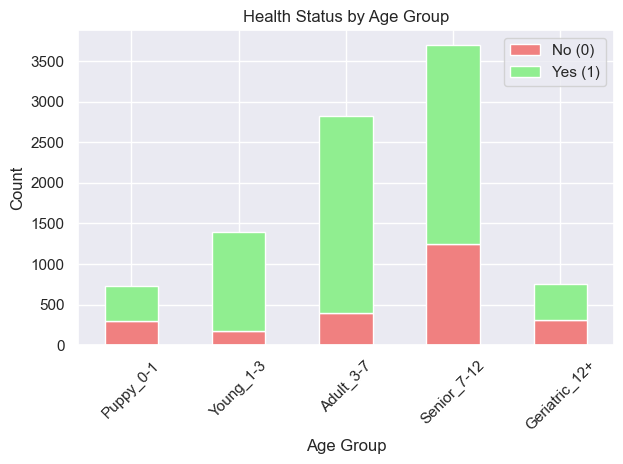

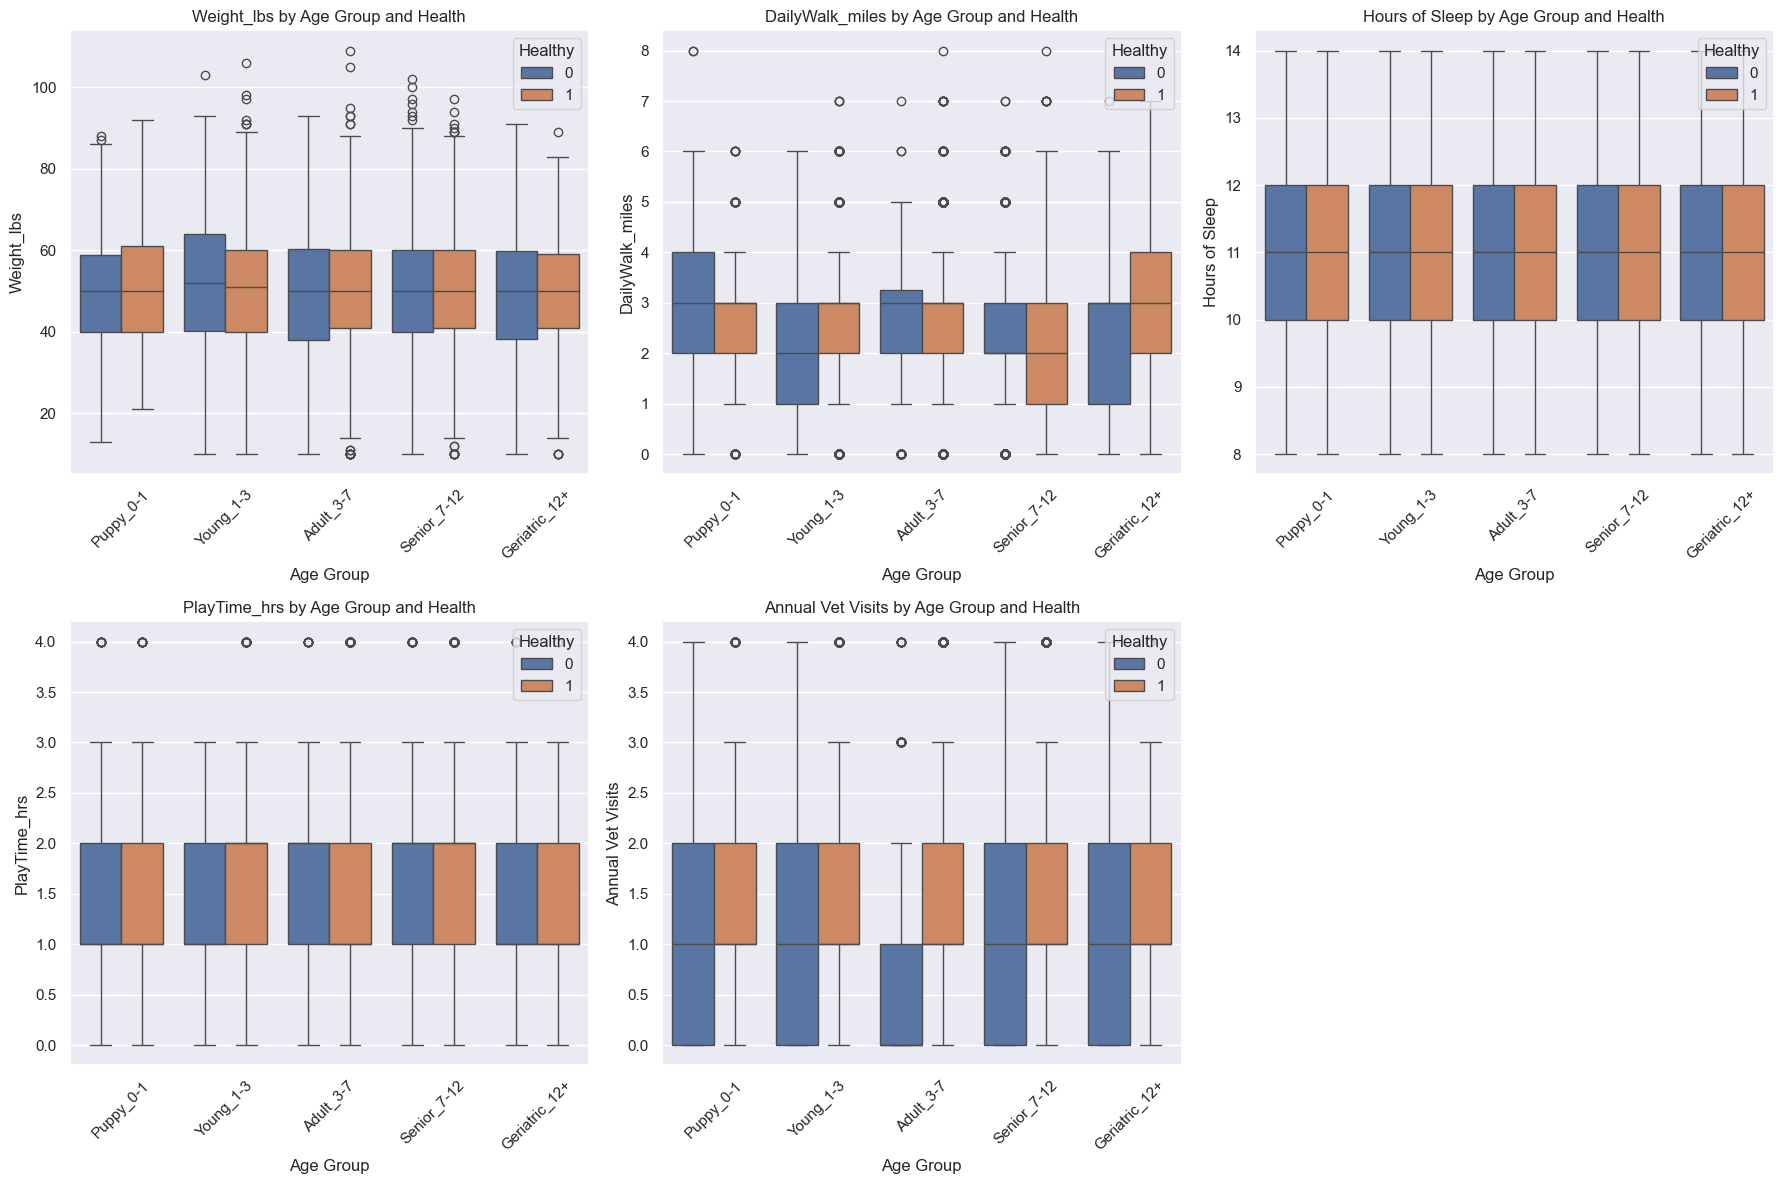


Correlation Analysis by Age Group (Key Health Features):


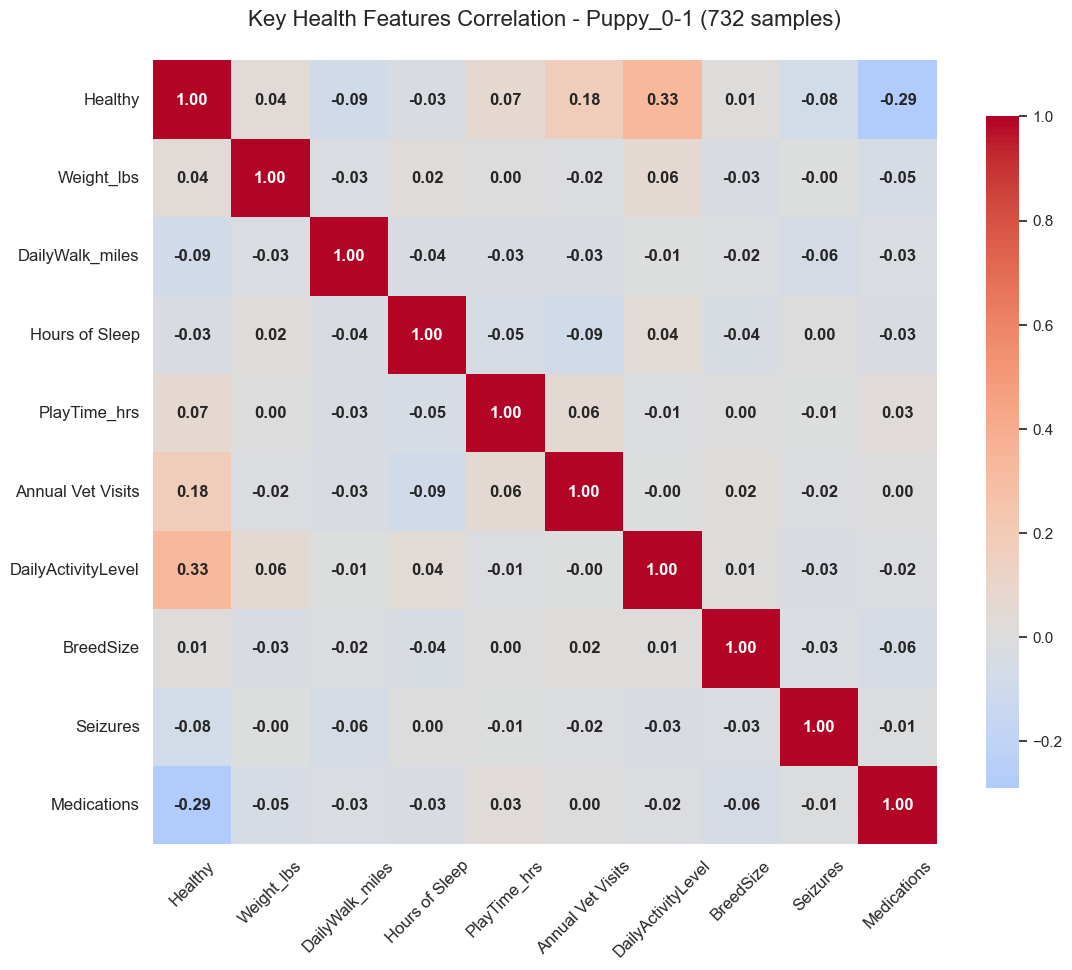


Top correlations with Healthy in Puppy_0-1:
DailyActivityLevel    0.333924
Medications          -0.290531
Annual Vet Visits     0.178279
DailyWalk_miles      -0.085027
Seizures             -0.079953
PlayTime_hrs          0.068064
Weight_lbs            0.035387
Hours of Sleep       -0.029965
Name: Healthy, dtype: float64


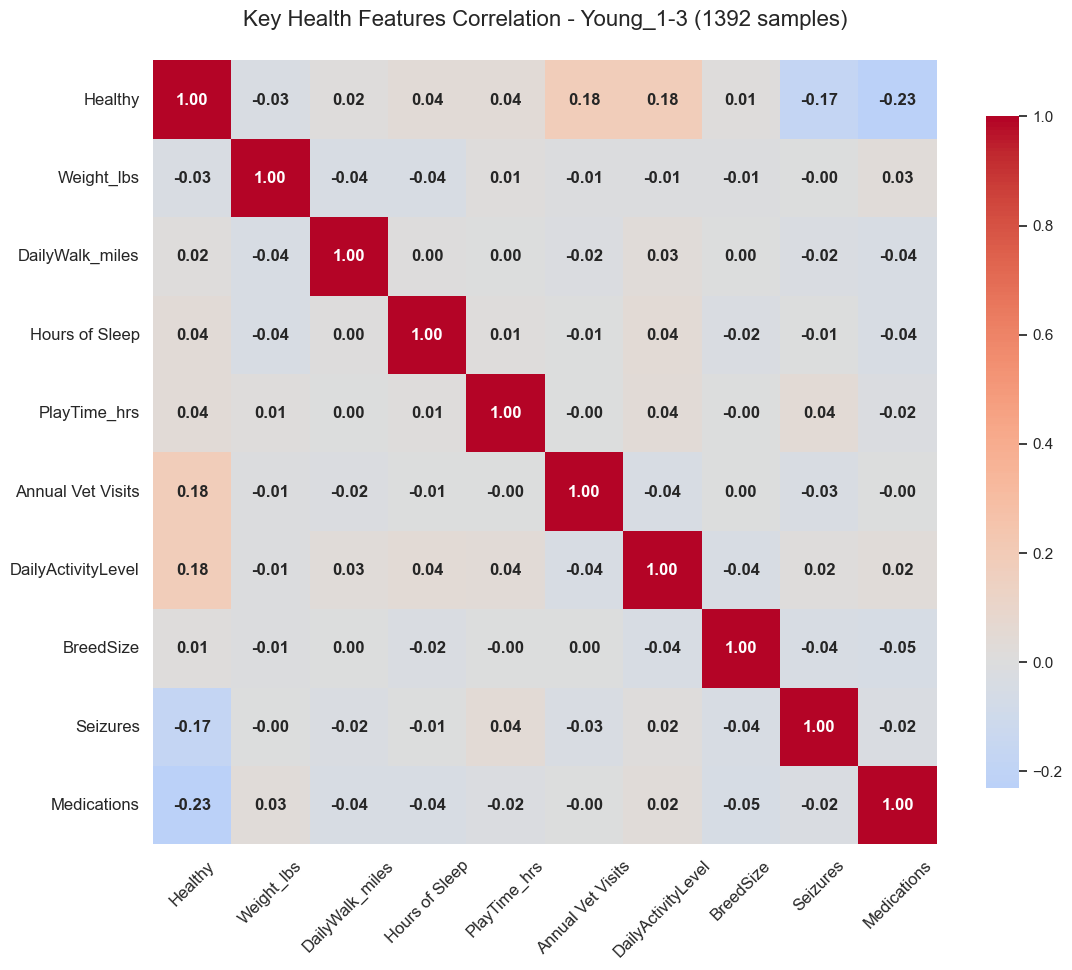


Top correlations with Healthy in Young_1-3:
Medications          -0.232507
DailyActivityLevel    0.182606
Annual Vet Visits     0.182556
Seizures             -0.174095
Hours of Sleep        0.041427
PlayTime_hrs          0.037196
Weight_lbs           -0.033355
DailyWalk_miles       0.016720
Name: Healthy, dtype: float64


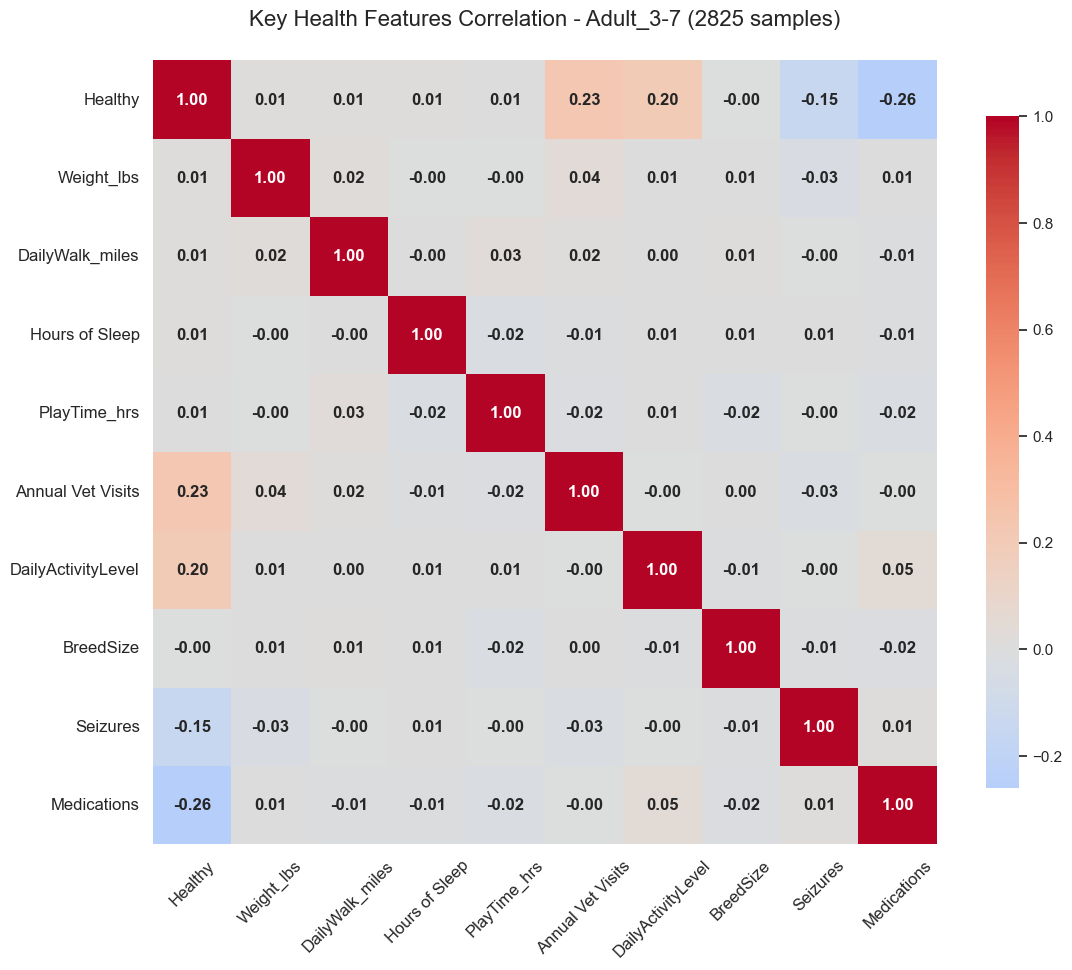


Top correlations with Healthy in Adult_3-7:
Medications          -0.261456
Annual Vet Visits     0.229834
DailyActivityLevel    0.198316
Seizures             -0.148956
Hours of Sleep        0.012573
Weight_lbs            0.012229
DailyWalk_miles       0.010958
PlayTime_hrs          0.006189
Name: Healthy, dtype: float64


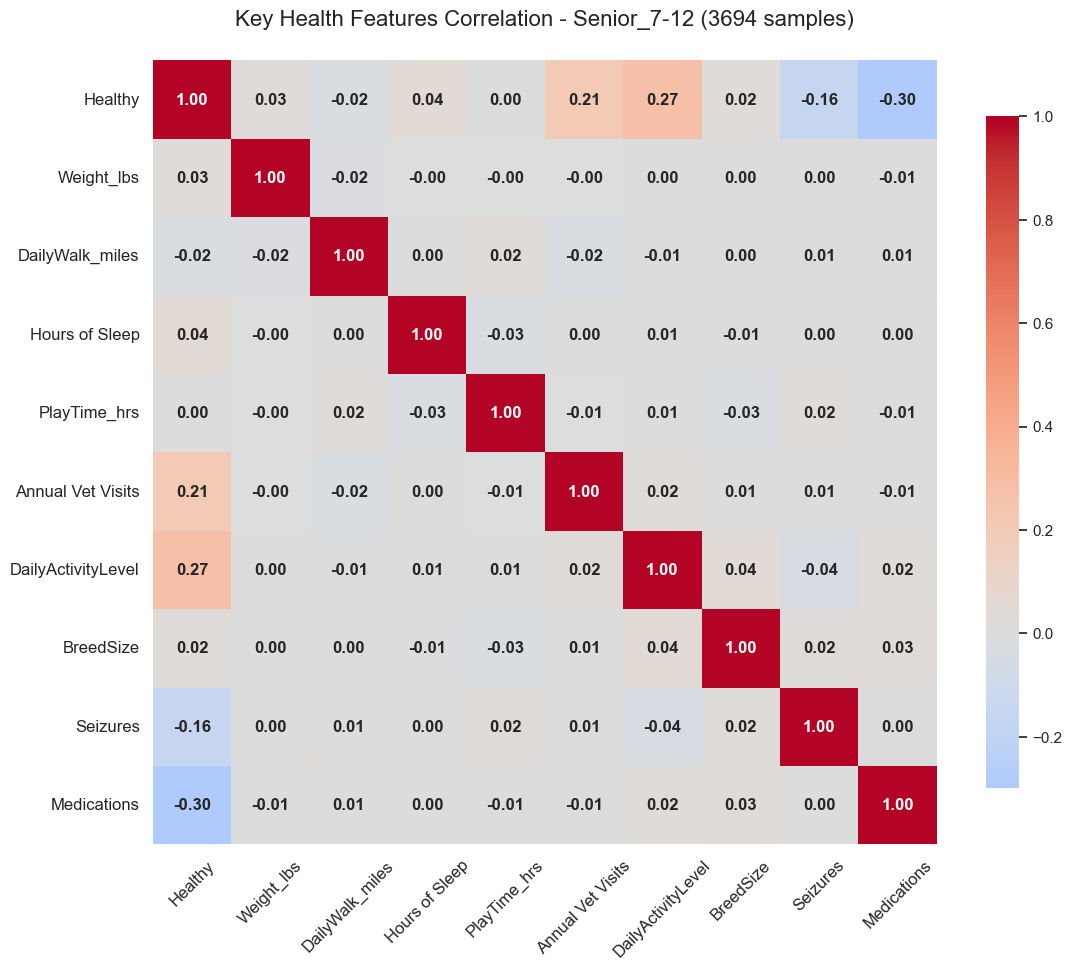


Top correlations with Healthy in Senior_7-12:
Medications          -0.299908
DailyActivityLevel    0.274909
Annual Vet Visits     0.206543
Seizures             -0.158242
Hours of Sleep        0.042836
Weight_lbs            0.027448
DailyWalk_miles      -0.024485
BreedSize             0.017359
Name: Healthy, dtype: float64


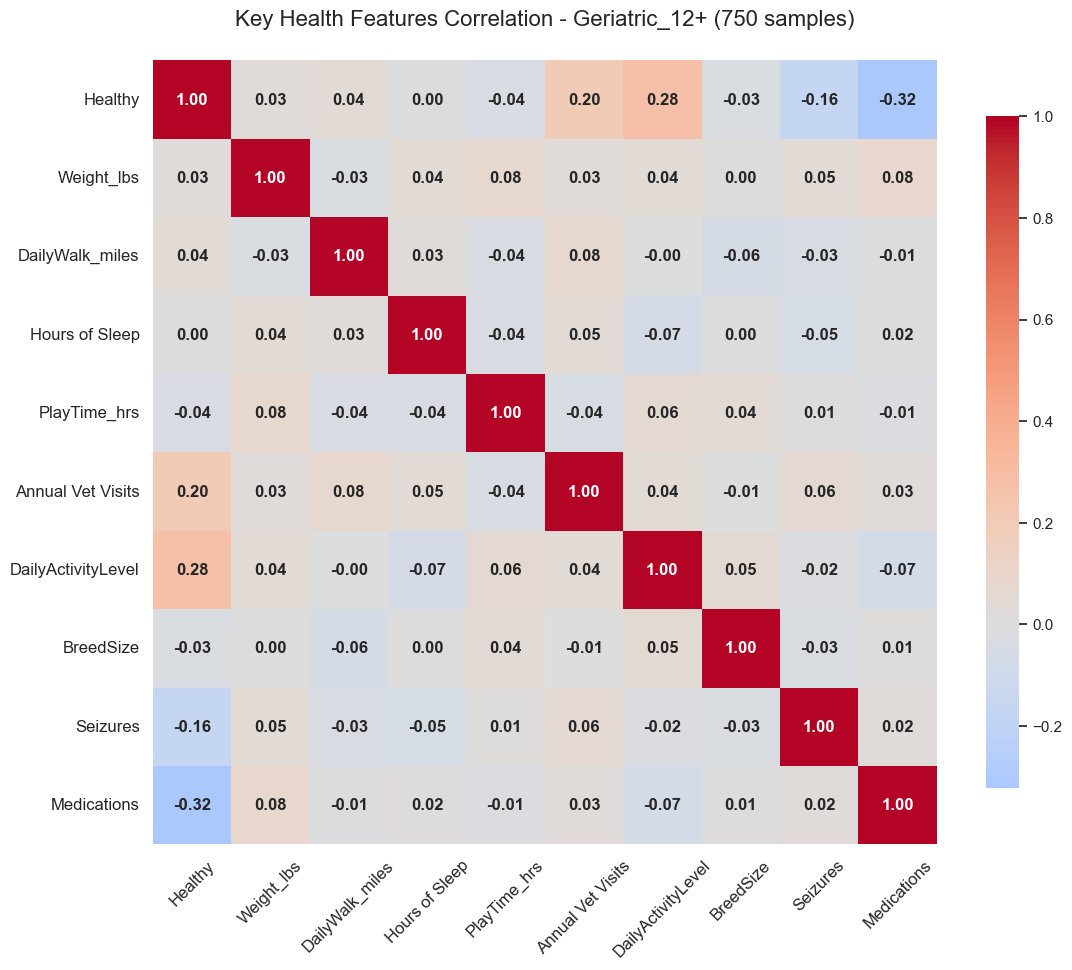


Top correlations with Healthy in Geriatric_12+:
Medications          -0.323334
DailyActivityLevel    0.281437
Annual Vet Visits     0.195129
Seizures             -0.164349
DailyWalk_miles       0.041860
PlayTime_hrs         -0.038675
Weight_lbs            0.027593
BreedSize            -0.026693
Name: Healthy, dtype: float64


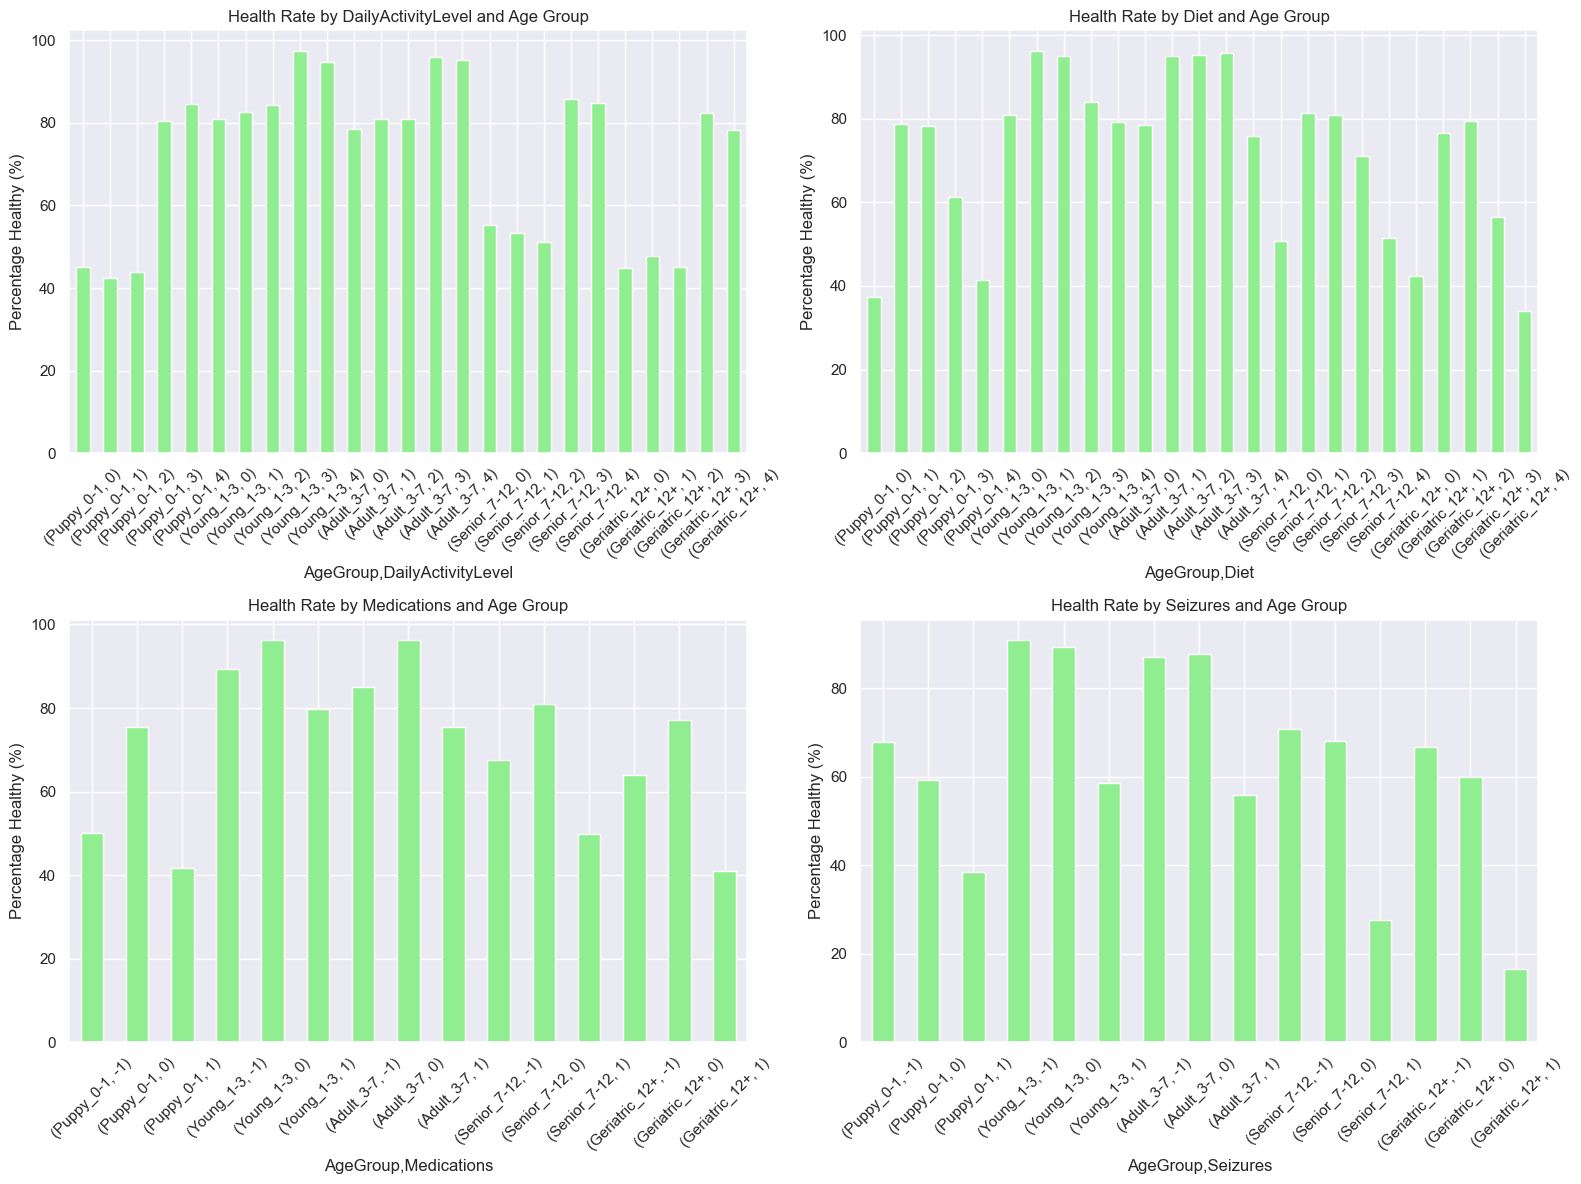


Feature Importance Analysis:


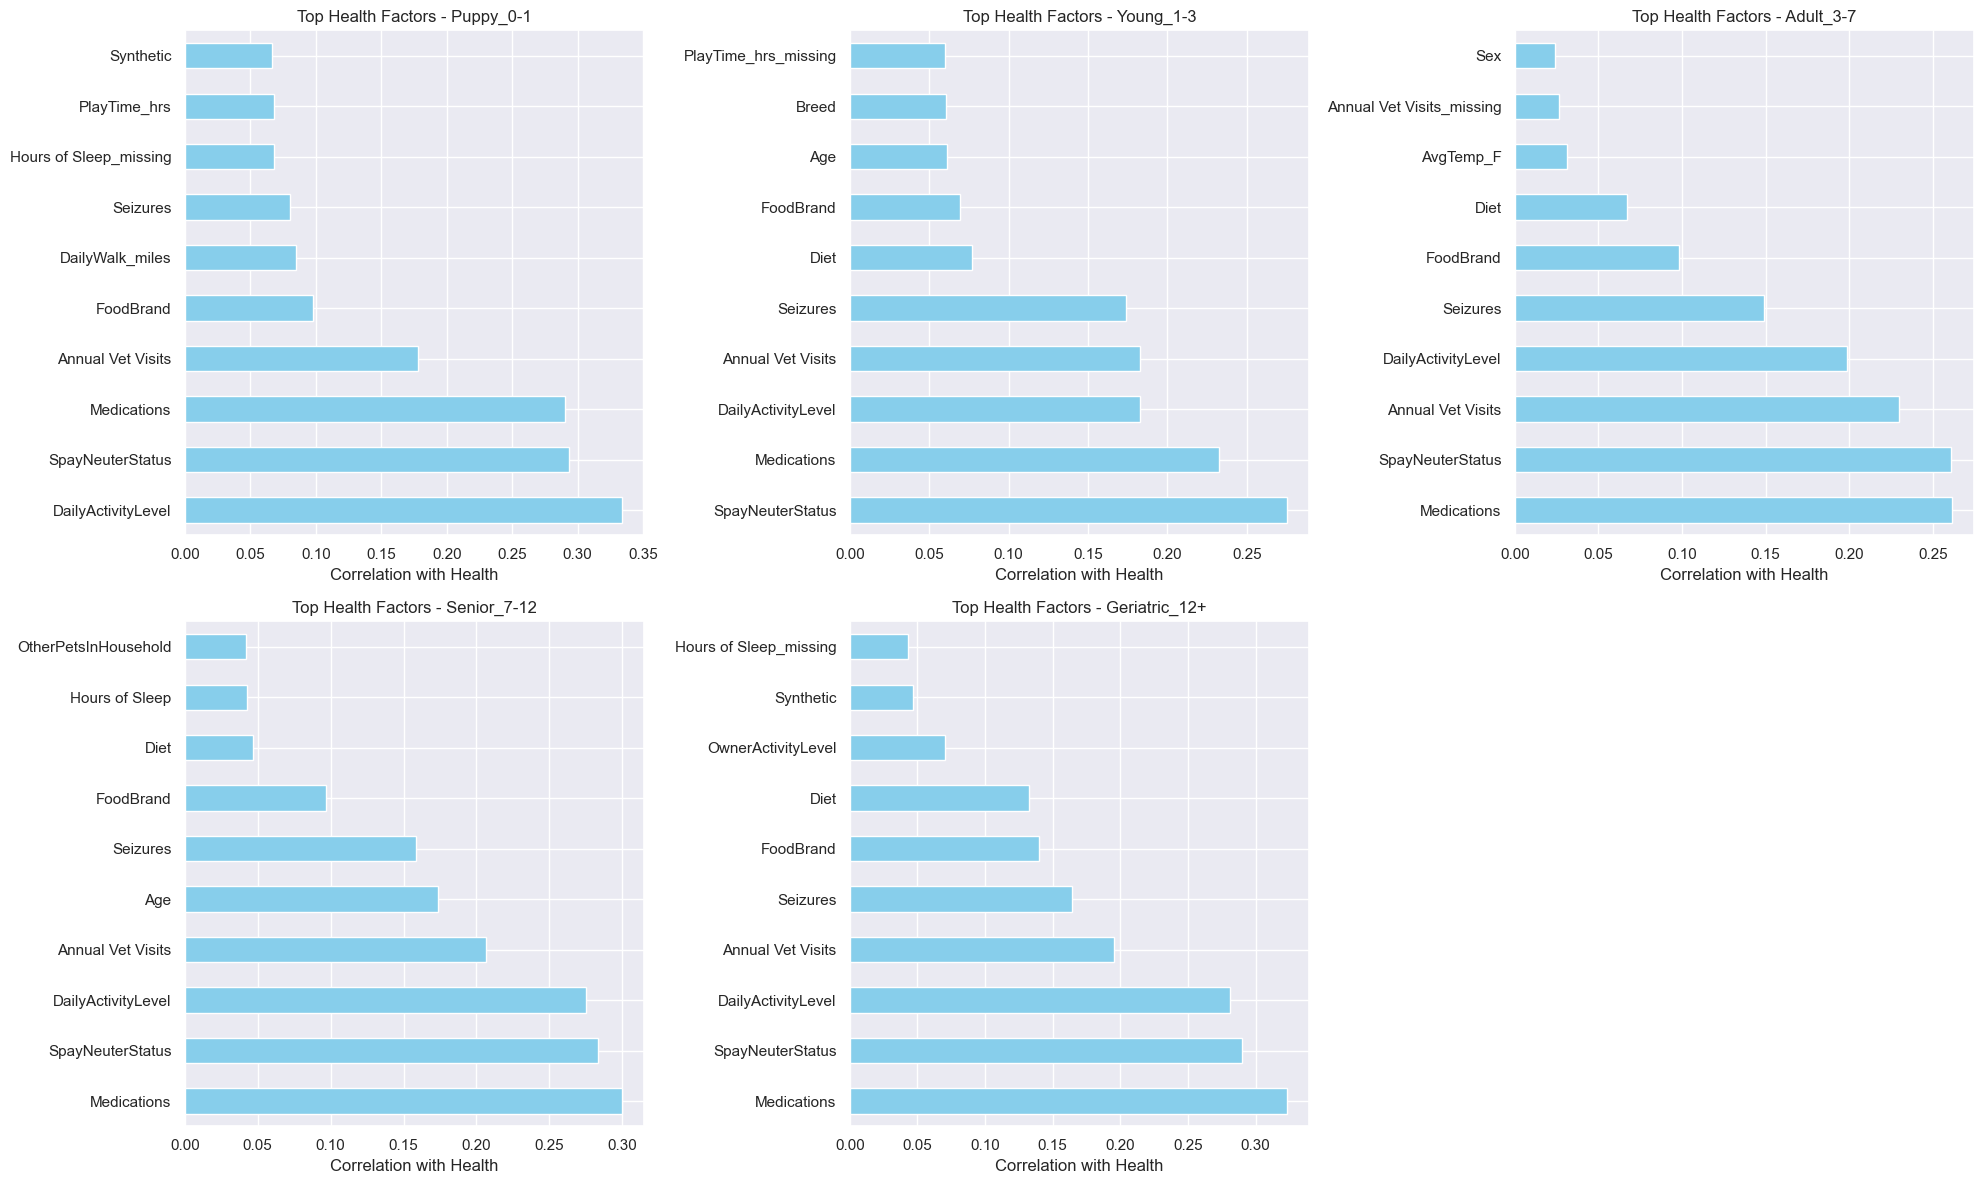


Data Visualization complete. Key insights:
- Age group distributions and health patterns
- Feature correlations by age group
- Health factor importance across different age groups


In [13]:
# Overall dataset overview
print("Dataset Overview:")
print(f"Total samples: {len(df)}")
print(f"Age groups: {df['AgeGroup'].value_counts().to_dict()}")
print(f"Health status: {df['Healthy'].value_counts().to_dict()}")

# 1. Health status by age group
plt.figure(figsize=(10, 6))
health_by_age = pd.crosstab(df['AgeGroup'], df['Healthy'])
health_by_age.plot(kind='bar', stacked=True, color=['lightcoral', 'lightgreen'])
plt.title('Health Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(['No (0)', 'Yes (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Key numeric features by age group and health status
key_features = ['Weight_lbs', 'DailyWalk_miles', 'Hours of Sleep', 'PlayTime_hrs', 'Annual Vet Visits']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    if i < len(axes):
        # Box plot by age group and health
        sns.boxplot(data=df, x='AgeGroup', y=feature, hue='Healthy', ax=axes[i])
        axes[i].set_title(f'{feature} by Age Group and Health')
        axes[i].set_xlabel('Age Group')
        axes[i].tick_params(axis='x', rotation=45)
        # Standardize legend position
        axes[i].legend(title='Healthy', loc='upper right', bbox_to_anchor=(1, 1))

# Remove empty subplot
if len(key_features) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# 3. Correlation analysis by age group (focused on key health features)
print("\nCorrelation Analysis by Age Group (Key Health Features):")

# Select only the most important health-related features for correlation
key_health_features = [
    'Healthy', 'Weight_lbs', 'DailyWalk_miles', 'Hours of Sleep', 'PlayTime_hrs', 
    'Annual Vet Visits', 'DailyActivityLevel', 'BreedSize', 'Seizures', 'Medications'
]

for age_group in df['AgeGroup'].cat.categories:
    group_data = df[df['AgeGroup'] == age_group]
    if len(group_data) > 50:  # Only for groups with enough data
        # Filter to only key health features that exist in the data
        available_features = [col for col in key_health_features if col in group_data.columns]
        
        if len(available_features) > 3:
            fig, ax = plt.subplots(figsize=(14, 12))
            corr_matrix = group_data[available_features].corr()
            
            # Show full correlation matrix (n x n)
            sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                       square=True, center=0, cbar_kws={'shrink': 0.8}, ax=ax,
                       annot_kws={'size': 12, 'weight': 'bold'})
            ax.set_title(f'Key Health Features Correlation - {age_group} ({len(group_data)} samples)', 
                        fontsize=16, pad=25)
            ax.tick_params(axis='x', rotation=45, labelsize=12)
            ax.tick_params(axis='y', rotation=0, labelsize=12)
            plt.subplots_adjust(left=0.2, bottom=0.2, right=0.9, top=0.9)
            plt.show()
            
            # Also show correlation with Healthy specifically
            if 'Healthy' in available_features:
                healthy_corr = corr_matrix['Healthy'].drop('Healthy').sort_values(key=abs, ascending=False)
                print(f"\nTop correlations with Healthy in {age_group}:")
                print(healthy_corr.head(8))

# 4. Health factors comparison across age groups
health_factors = ['DailyActivityLevel', 'Diet', 'Medications', 'Seizures']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, factor in enumerate(health_factors):
    if i < len(axes):
        # Cross-tabulation of factor vs health by age group
        crosstab = pd.crosstab([df['AgeGroup'], df[factor]], df['Healthy'])
        crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
        
        # Plot percentage of healthy dogs (Healthy is now encoded as 1/0)
        if 1 in crosstab_pct.columns:
            healthy_pct = crosstab_pct[1]  # 1 represents healthy (Yes)
            healthy_pct.plot(kind='bar', ax=axes[i], color='lightgreen')
            axes[i].set_title(f'Health Rate by {factor} and Age Group')
            axes[i].set_ylabel('Percentage Healthy (%)')
            axes[i].tick_params(axis='x', rotation=45)
        else:
            # If no healthy data, show message
            axes[i].text(0.5, 0.5, f'No healthy data for {factor}', 
                        ha='center', va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'Health Rate by {factor} and Age Group')
            axes[i].set_ylabel('Percentage Healthy (%)')

plt.tight_layout()
plt.show()

# 5. Feature importance visualization (using correlation with health)
print("\nFeature Importance Analysis:")
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Healthy' in df.columns:
    # Healthy is already encoded as 1/0, no conversion needed
    # Calculate correlation with health for each age group
    importance_by_age = {}
    for age_group in df['AgeGroup'].cat.categories:
        group_data = df[df['AgeGroup'] == age_group]
        if len(group_data) > 30:
            correlations = group_data[numeric_features].corr()['Healthy'].abs()
            correlations = correlations.drop('Healthy').sort_values(ascending=False)
            importance_by_age[age_group] = correlations.head(10)
    
    # Plot feature importance by age group
    if importance_by_age:
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        axes = axes.ravel()
        
        for i, (age_group, importance) in enumerate(importance_by_age.items()):
            if i < len(axes) and len(importance) > 0:
                importance.plot(kind='barh', ax=axes[i], color='skyblue')
                axes[i].set_title(f'Top Health Factors - {age_group}')
                axes[i].set_xlabel('Correlation with Health')
        
        # Remove empty subplots
        for j in range(len(importance_by_age), len(axes)):
            fig.delaxes(axes[j])
        
        plt.tight_layout()
        plt.show()

print("\nData Visualization complete. Key insights:")
print("- Age group distributions and health patterns")
print("- Feature correlations by age group") 
print("- Health factor importance across different age groups")


## Prediction Model

### Model Selection Strategy

Our dataset has different types of information - some numbers (like weight and age) and some categories (like breed and activity level). We need to choose the right model to predict if a dog is healthy or not.

This is a classification problem where we predict if a dog is healthy(1) or not(0). Several models work well for this type of problem, such as Gradient Boosting, Random Forest, Logistic Regression, and Decision Tree.

First, we chose Gradient Boosting because it handles our mixed data types well, it can find important patterns automatically, and gives us clear feature importance rankings to understand which factors most affect canine health.

In [32]:
# Store results for each age group
age_group_results = {}

# Train models for each age group
for age_group in df['AgeGroup'].cat.categories:
    print(f"\n--- Training model for {age_group} ---")
    
    # Filter data for this age group
    group_data = df[df['AgeGroup'] == age_group].copy()
    
    if len(group_data) < 50:  # Skip groups with too few samples
        print(f"Skipping {age_group} - insufficient samples ({len(group_data)})")
        continue
    
    # Prepare features and target
    X_group = group_data.drop(['Healthy', 'AgeGroup'], axis=1)
    y_group = group_data['Healthy']
    
    # Split data
    X_train_group, X_test_group, y_train_group, y_test_group = train_test_split(
        X_group, y_group, test_size=0.2, random_state=42, stratify=y_group
    )
    
    # Train Gradient Boosting model
    gb_group = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
    
    gb_group.fit(X_train_group, y_train_group)
    
    # Make predictions
    y_pred_group = gb_group.predict(X_test_group)
    y_pred_proba_group = gb_group.predict_proba(X_test_group)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_group, y_pred_group)
    precision = precision_score(y_test_group, y_pred_group)
    recall = recall_score(y_test_group, y_pred_group)
    auc = roc_auc_score(y_test_group, y_pred_proba_group)
    
    # Get top 3 most important features
    feature_importance = gb_group.feature_importances_
    feature_names = X_group.columns
    importance_df_group = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False)
    
    top_3_features = importance_df_group.head(3)
    
    # Store results
    age_group_results[age_group] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'auc': auc,
        'top_3_features': top_3_features,
        'sample_size': len(group_data)
    }
    
    print(f"Sample size: {len(group_data)}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"Top 3 Features:")
    for idx, row in top_3_features.iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.4f}")



--- Training model for Puppy_0-1 ---
Sample size: 732
Accuracy: 0.9320
Precision: 0.9222
Recall: 0.9651
AUC-ROC: 0.9758
Top 3 Features:
  Diet: 0.2585
  DailyActivityLevel: 0.1560
  Medications: 0.1456

--- Training model for Young_1-3 ---
Sample size: 1392
Accuracy: 0.9427
Precision: 0.9455
Recall: 0.9918
AUC-ROC: 0.9538
Top 3 Features:
  DailyActivityLevel: 0.1736
  Diet: 0.1697
  Medications: 0.1478

--- Training model for Adult_3-7 ---
Sample size: 2825
Accuracy: 0.9752
Precision: 0.9817
Recall: 0.9897
AUC-ROC: 0.9814
Top 3 Features:
  Diet: 0.2141
  Medications: 0.1573
  DailyActivityLevel: 0.1563

--- Training model for Senior_7-12 ---
Sample size: 3694
Accuracy: 0.9540
Precision: 0.9559
Recall: 0.9755
AUC-ROC: 0.9877
Top 3 Features:
  Diet: 0.2142
  DailyActivityLevel: 0.1466
  Medications: 0.1356

--- Training model for Geriatric_12+ ---
Sample size: 750
Accuracy: 0.9333
Precision: 0.9231
Recall: 0.9655
AUC-ROC: 0.9823
Top 3 Features:
  Diet: 0.2076
  Medications: 0.1400
  Ann

In [33]:
# Test models using only top 3 features for each age group
print("\n=== TESTING MODELS WITH TOP 3 FEATURES ONLY ===")

top3_results = {}

for age_group, results in age_group_results.items():
    print(f"\n--- Testing {age_group} with top 3 features only ---")
    
    # Get the top 3 feature names
    top_3_feature_names = results['top_3_features']['Feature'].tolist()
    print(f"Top 3 features: {top_3_feature_names}")
    
    # Filter data for this age group
    group_data = df[df['AgeGroup'] == age_group].copy()
    
    # Prepare features using only top 3
    X_group_top3 = group_data[top_3_feature_names]
    y_group = group_data['Healthy']
    
    # Split data
    X_train_top3, X_test_top3, y_train_top3, y_test_top3 = train_test_split(
        X_group_top3, y_group, test_size=0.2, random_state=42, stratify=y_group
    )
    
    # Train model with only top 3 features
    gb_top3 = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    )
    
    gb_top3.fit(X_train_top3, y_train_top3)
    
    # Make predictions
    y_pred_top3 = gb_top3.predict(X_test_top3)
    
    # Calculate accuracy
    accuracy_top3 = accuracy_score(y_test_top3, y_pred_top3)
    
    # Store results
    top3_results[age_group] = {
        'features': top_3_feature_names,
        'accuracy': accuracy_top3,
        'original_accuracy': results['accuracy']
    }
    
    print(f"Accuracy with top 3 features: {accuracy_top3:.4f}")
    print(f"Original accuracy (all features): {results['accuracy']:.4f}")
    print(f"Accuracy difference: {abs(accuracy_top3 - results['accuracy']):.4f}")

# Summary table
print("\n=== SUMMARY TABLE ===")
print("Age Group | Sample Size | All Features Acc | Top 3 Acc | Difference")
print("-" * 70)
for age_group, results in age_group_results.items():
    if age_group in top3_results:
        print(f"{age_group:12} | {results['sample_size']:10} | {results['accuracy']:15.4f} | {top3_results[age_group]['accuracy']:9.4f} | {abs(top3_results[age_group]['accuracy'] - results['accuracy']):10.4f}")



=== TESTING MODELS WITH TOP 3 FEATURES ONLY ===

--- Testing Puppy_0-1 with top 3 features only ---
Top 3 features: ['Diet', 'DailyActivityLevel', 'Medications']
Accuracy with top 3 features: 0.7007
Original accuracy (all features): 0.9320
Accuracy difference: 0.2313

--- Testing Young_1-3 with top 3 features only ---
Top 3 features: ['DailyActivityLevel', 'Diet', 'Medications']
Accuracy with top 3 features: 0.8530
Original accuracy (all features): 0.9427
Accuracy difference: 0.0896

--- Testing Adult_3-7 with top 3 features only ---
Top 3 features: ['Diet', 'Medications', 'DailyActivityLevel']
Accuracy with top 3 features: 0.8619
Original accuracy (all features): 0.9752
Accuracy difference: 0.1133

--- Testing Senior_7-12 with top 3 features only ---
Top 3 features: ['Diet', 'DailyActivityLevel', 'Medications']
Accuracy with top 3 features: 0.7632
Original accuracy (all features): 0.9540
Accuracy difference: 0.1908

--- Testing Geriatric_12+ with top 3 features only ---
Top 3 feature


=== VISUALIZATION OF AGE-GROUP RESULTS ===


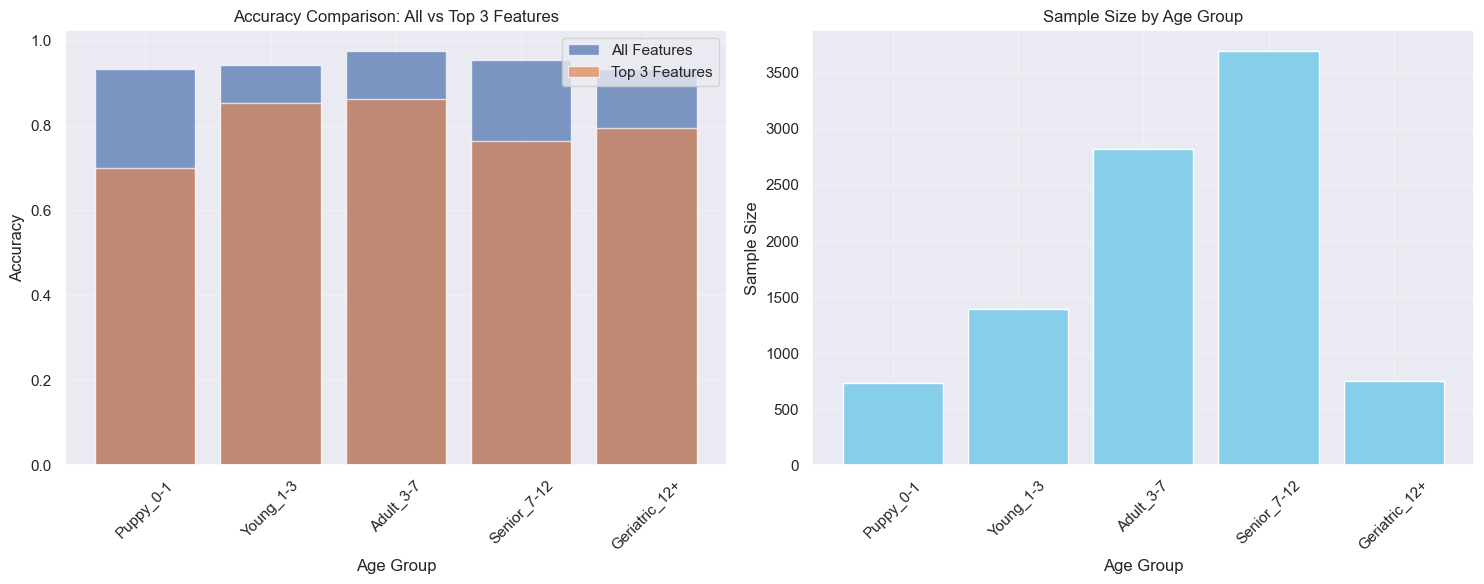

In [34]:
# Visualize age-group specific results
print("\n=== VISUALIZATION OF AGE-GROUP RESULTS ===")

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Accuracy comparison across age groups
age_groups = list(age_group_results.keys())
accuracies = [age_group_results[group]['accuracy'] for group in age_groups]
top3_accuracies = [top3_results[group]['accuracy'] for group in age_groups if group in top3_results]

axes[0].bar(range(len(age_groups)), accuracies, alpha=0.7, label='All Features')
axes[0].bar(range(len(age_groups)), top3_accuracies, alpha=0.7, label='Top 3 Features')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy Comparison: All vs Top 3 Features')
axes[0].set_xticks(range(len(age_groups)))
axes[0].set_xticklabels(age_groups, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Sample sizes
sample_sizes = [age_group_results[group]['sample_size'] for group in age_groups]
axes[1].bar(range(len(age_groups)), sample_sizes, color='skyblue')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Sample Size')
axes[1].set_title('Sample Size by Age Group')
axes[1].set_xticks(range(len(age_groups)))
axes[1].set_xticklabels(age_groups, rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Then, we create model with SVM to see if we can get better performance.

In [35]:
# SVM Analysis by Age Group
print("=== SVM ANALYSIS BY AGE GROUP ===")

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Store SVM results for each age group
svm_age_group_results = {}

# Train SVM models for each age group
for age_group in df['AgeGroup'].cat.categories:
    print(f"\n--- Training SVM for {age_group} ---")
    
    # Filter data for this age group
    group_data = df[df['AgeGroup'] == age_group].copy()
    
    if len(group_data) < 50:  # Skip groups with too few samples
        print(f"Skipping {age_group} - insufficient samples ({len(group_data)})")
        continue
    
    # Prepare features and target
    X_group = group_data.drop(['Healthy', 'AgeGroup'], axis=1)
    y_group = group_data['Healthy']
    
    # Split data
    X_train_group, X_test_group, y_train_group, y_test_group = train_test_split(
        X_group, y_group, test_size=0.2, random_state=42, stratify=y_group
    )
    
    # Standardize features for SVM
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_group)
    X_test_scaled = scaler.transform(X_test_group)
    
    # Train SVM model
    svm_group = SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    )
    
    svm_group.fit(X_train_scaled, y_train_group)
    
    # Make predictions
    y_pred_svm = svm_group.predict(X_test_scaled)
    y_pred_proba_svm = svm_group.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy_svm = accuracy_score(y_test_group, y_pred_svm)
    precision_svm = precision_score(y_test_group, y_pred_svm)
    recall_svm = recall_score(y_test_group, y_pred_svm)
    f1_svm = f1_score(y_test_group, y_pred_svm)
    auc_svm = roc_auc_score(y_test_group, y_pred_proba_svm)
    
    # Store results
    svm_age_group_results[age_group] = {
        'accuracy': accuracy_svm,
        'precision': precision_svm,
        'recall': recall_svm,
        'f1': f1_svm,
        'auc': auc_svm,
        'sample_size': len(group_data)
    }
    
    print(f"Sample size: {len(group_data)}")
    print(f"SVM Accuracy: {accuracy_svm:.4f}")
    print(f"SVM Precision: {precision_svm:.4f}")
    print(f"SVM Recall: {recall_svm:.4f}")
    print(f"SVM F1-Score: {f1_svm:.4f}")
    print(f"SVM AUC-ROC: {auc_svm:.4f}")


=== SVM ANALYSIS BY AGE GROUP ===

--- Training SVM for Puppy_0-1 ---
Sample size: 732
SVM Accuracy: 0.8027
SVM Precision: 0.7767
SVM Recall: 0.9302
SVM F1-Score: 0.8466
SVM AUC-ROC: 0.8969

--- Training SVM for Young_1-3 ---
Sample size: 1392
SVM Accuracy: 0.9104
SVM Precision: 0.9135
SVM Recall: 0.9918
SVM F1-Score: 0.9511
SVM AUC-ROC: 0.8673

--- Training SVM for Adult_3-7 ---
Sample size: 2825
SVM Accuracy: 0.9009
SVM Precision: 0.9043
SVM Recall: 0.9897
SVM F1-Score: 0.9451
SVM AUC-ROC: 0.8962

--- Training SVM for Senior_7-12 ---
Sample size: 3694
SVM Accuracy: 0.8444
SVM Precision: 0.8438
SVM Recall: 0.9387
SVM F1-Score: 0.8887
SVM AUC-ROC: 0.9263

--- Training SVM for Geriatric_12+ ---
Sample size: 750
SVM Accuracy: 0.7733
SVM Precision: 0.7732
SVM Recall: 0.8621
SVM F1-Score: 0.8152
SVM AUC-ROC: 0.8533


In [36]:
# Compare Gradient Boosting vs SVM results
print("\n=== GRADIENT BOOSTING vs SVM COMPARISON ===")

# Create comparison table
print("Age Group | Sample Size | GB Accuracy | SVM Accuracy | Difference")
print("-" * 70)
for age_group in age_group_results.keys():
    if age_group in svm_age_group_results:
        gb_acc = age_group_results[age_group]['accuracy']
        svm_acc = svm_age_group_results[age_group]['accuracy']
        diff = gb_acc - svm_acc
        sample_size = age_group_results[age_group]['sample_size']
        print(f"{age_group:12} | {sample_size:10} | {gb_acc:11.4f} | {svm_acc:11.4f} | {diff:10.4f}")

# Calculate average performance
gb_accuracies = [age_group_results[group]['accuracy'] for group in age_group_results.keys()]
svm_accuracies = [svm_age_group_results[group]['accuracy'] for group in svm_age_group_results.keys()]

print(f"\nAverage Gradient Boosting Accuracy: {np.mean(gb_accuracies):.4f}")
print(f"Average SVM Accuracy: {np.mean(svm_accuracies):.4f}")
print(f"Average Difference (GB - SVM): {np.mean(gb_accuracies) - np.mean(svm_accuracies):.4f}")

# Find best performing age group for each method
best_gb_group = max(age_group_results.keys(), key=lambda x: age_group_results[x]['accuracy'])
best_svm_group = max(svm_age_group_results.keys(), key=lambda x: svm_age_group_results[x]['accuracy'])

print(f"\nBest Gradient Boosting Performance: {best_gb_group} ({age_group_results[best_gb_group]['accuracy']:.4f})")
print(f"Best SVM Performance: {best_svm_group} ({svm_age_group_results[best_svm_group]['accuracy']:.4f})")



=== GRADIENT BOOSTING vs SVM COMPARISON ===
Age Group | Sample Size | GB Accuracy | SVM Accuracy | Difference
----------------------------------------------------------------------
Puppy_0-1    |        732 |      0.9320 |      0.8027 |     0.1293
Young_1-3    |       1392 |      0.9427 |      0.9104 |     0.0323
Adult_3-7    |       2825 |      0.9752 |      0.9009 |     0.0743
Senior_7-12  |       3694 |      0.9540 |      0.8444 |     0.1096
Geriatric_12+ |        750 |      0.9333 |      0.7733 |     0.1600

Average Gradient Boosting Accuracy: 0.9474
Average SVM Accuracy: 0.8463
Average Difference (GB - SVM): 0.1011

Best Gradient Boosting Performance: Adult_3-7 (0.9752)
Best SVM Performance: Young_1-3 (0.9104)


**After running the same dataset with both Gradient Boosting and SVM models, we found out that Gradient Boosting outperformed SVM across all age groups.**

## Conclusion

### Key Findings from Age-Group Analysis

**Top 3 Features by Age Group:**
- **Puppy (0-1 years)**: Diet, DailyActivityLevel, Medications
- **Young (1-3 years)**: DailyActivityLevel, Diet, Medications  
- **Adult (3-7 years)**: Diet, Medications, DailyActivityLevel
- **Senior (7-12 years)**: Diet, DailyActivityLevel, Medications
- **Geriatric (12+ years)**: Diet, Medications, Annual Vet Visits

**Pattern Analysis:**
1. **Diet is consistently the most important factor** across all age groups, showing that nutrition plays a crucial role in canine health at every life stage.

2. **Activity level importance varies by age**: DailyActivityLevel is most critical for young dogs (1-3 years) but becomes less important for geriatric dogs (12+ years), where Annual Vet Visits becomes more significant.

3. **Medications show consistent importance** across all age groups, indicating that medical intervention is a key health indicator regardless of age.

**Accuracy Impact of Using Only Top 3 Features:**
- **Young dogs (1-3 years)**: Smallest accuracy drop (8.96%), suggesting these 3 features capture most health patterns
- **Puppies (0-1 years)**: Largest accuracy drop (23.13%), indicating more complex health factors at play
- **Adult dogs (3-7 years)**: Moderate drop (11.33%), showing balanced feature importance
- **Senior dogs (7-12 years)**: Significant drop (19.08%), suggesting age-related health complexity
- **Geriatric dogs (12+ years)**: Moderate drop (14.00%), with vet visits becoming more important than activity

**Age-specific patterns**: 
- Young dogs need more activity for development
- Older dogs rely more on medical care and vet monitoring
- Puppies have complex growth factors beyond the top 3 features

**Accuracy differences**: Younger dogs have simpler health patterns, while older dogs have more complex, multi-factor health issues.